# image_classification-mnist-ffnn-numpy

A from-scratch feed-forward neural network trained on MNIST in pure NumPy.

# 1. Overview

## 1.1 Task & motivation

Image classification of 28×28 grayscale MNIST digits into 10 classes, used here as a vehicle for hand-coding every primitive of a small neural network — no PyTorch, no autograd. The result is a working classifier whose every gradient and update is visible in this folder's source files.

## 1.2 Dataset summary

MNIST (60,000 training images, 10,000 test images). Loaded via `torchvision.datasets.MNIST` and converted to NumPy arrays.

## 1.3 Approach in one paragraph

A `FeedFwdNN` instance composes an ordered list of layers (`LinearLayer`, `ReluLayer`, `SoftmaxCrossEntropyLayer`). Forward chains them; backward iterates in reverse, applying the chain rule. Two networks are trained: a shallow `[784→128→10]` and a deeper `[784→256→128→10]`, both with mini-batch SGD. Per-iteration training/validation losses are tracked into `IterationDataPoint` objects and plotted.

## 1.4 Libraries used

| Library | Used for |
|---|---|
| `numpy` | All linear algebra and gradient math |
| `torchvision` | MNIST dataset loading only |

# 2. Environment & Setup

## 2.1 Imports

Cells 2 and 5 import NumPy, torchvision, and the sibling layer modules (`LinearLayer`, `ReluLayer`, `SoftmaxCrossEntropyLayer`, `FeedFwdNN`, `IterationDataPoint`, `Utils`, `Consts`).

## 2.2 Configuration / hyperparameters

The papermill parameters cell sets `SMOKE_TEST` and `SMOKE_TEST_EPOCHS`. Each network's epoch count, batch size, and learning rate are inlined at construction.

## 2.3 Reproducibility (seed, device)

Pure-NumPy execution on CPU. NumPy seeding is handled inside the layer initializers (Xavier-style).

# 3. Data

## 3.1 Loading

Cells 3–4 download MNIST into `./data/` (gitignored) and produce train/val splits.

## 3.2 Inspection / EDA

Inline summary printing; no separate EDA section since MNIST is well-known.

## 3.3 Preprocessing & splits

Images flattened to 784-dim vectors; labels one-hot encoded inside the network's loss layer.

# 4. Model

## 4.1 Architecture

Two `FeedFwdNN` instances:

- **net1**: `[784 → 128 → 10]` with `ReluLayer` + `SoftmaxCrossEntropyLayer`.
- **net2**: `[784 → 256 → 128 → 10]` — same activations, deeper.

## 4.2 Loss & optimizer

Combined softmax + cross-entropy (computed jointly in `SoftmaxCrossEntropyLayer` for gradient stability). Vanilla mini-batch SGD; no momentum or adaptive method.

## 4.3 Why this design

The simplest possible architectures that can clear MNIST cleanly, kept identical-in-shape between the two depths to isolate the effect of one extra hidden layer.

# 5. Training

## 5.1 Training loop

`FeedFwdNN.train()` (in `feed_fwd_nn.py`) iterates batches; for each batch it forwards through the layer list, backwards in reverse order, then updates each layer's parameters.

## 5.2 Metrics tracked

Per-iteration training loss, validation loss, and validation accuracy stored as `IterationDataPoint` objects in `net1_idps` / `net2_idps`.

## 5.3 Run-time notes

Tier A — total wall time well under 5 minutes on CPU.

# 6. Evaluation & Results

## 6.1 Test-set evaluation

The best-iteration validation loss is reported for each network at the end (cells 10–11).

## 6.2 Visualizations

`Utils.two_line_plot` (cells 7, 9) renders training vs. validation loss curves for net1 and net2.

## 6.3 Discussion

The deeper network reaches a lower validation loss but requires more iterations to converge. With only two depths and no regularization, this is a controlled demonstration rather than a hyperparameter sweep.


In [1]:
SMOKE_TEST = 0
SMOKE_TEST_EPOCHS = 10


In [2]:
# Parameters
SMOKE_TEST = 1


In [3]:
import numpy as np
import torchvision as thv

from utils import Utils
from consts import Consts
from feed_fwd_nn import FeedFwdNN

/opt/conda/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/conda/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [4]:
ds_train = thv.datasets.MNIST(
    root="./data"
    , train=True
    , download=True
    , transform=thv.transforms.Compose(
        [
            thv.transforms.ToTensor()
            , thv.transforms.Normalize(mean=Consts.DS_MEAN, std=Consts.DS_STD)
        ]
    )
)

idx_train = np.random.randint(
    low=0
    , high=ds_train.data.shape[0]
    , size=int(ds_train.data.shape[0] * Consts.DS_SAMPLING_RATIO)
)

X_train = (
    ds_train.data
    .numpy()
    .reshape(-1, Consts.FEATURES_SIZE_IN)
)
    
Y_train = Utils.one_hot_encode(
    X=ds_train.targets.numpy()
    , C=[int(cls[0:1]) for cls in ds_train.classes]
)

print(idx_train.shape)
print(X_train.shape)
print(Y_train.shape)

(60000,)
(60000, 784)
(60000, 10)


In [5]:
ds_val = thv.datasets.MNIST(
    root="./data"
    , train=False
    , download=True
    , transform=thv.transforms.Compose(
        [
            thv.transforms.ToTensor()
            , thv.transforms.Normalize(mean=Consts.DS_MEAN, std=Consts.DS_STD)
        ]
    )
)

idx_val = np.arange(0, int(ds_val.data.shape[0] * Consts.DS_SAMPLING_RATIO))

X_val = (
    ds_val.data
    .numpy()
    .reshape(-1, Consts.FEATURES_SIZE_IN)
)
    
Y_val = Utils.one_hot_encode(
    X=ds_val.targets.numpy()
    , C=[int(cls[0:1]) for cls in ds_val.classes]
)

print(idx_val.shape)
print(X_val.shape)
print(Y_val.shape)

(10000,)
(10000, 784)
(10000, 10)


In [6]:
from linear_layer import LinearLayer
from relu_layer import ReluLayer
from softmax_cross_entropy_layer import SoftmaxCrossEntropyLayer

L1 = LinearLayer(feature_size_in=Consts.FEATURES_SIZE_IN, feature_size_out=Consts.FEATURES_SIZE_OUT)
L2 = ReluLayer(feature_size=Consts.FEATURES_SIZE_OUT)
L3 = SoftmaxCrossEntropyLayer(feature_size=Consts.FEATURES_SIZE_OUT)

for I in Utils.mini_batchify(np.arange(0, 1), 1):
    X, Y = X_train[I], Y_train[I]

    A1 = L1.forward(X)
    A2 = L2.forward(A1)
    A3 = L3.forward(A2, Y)

    dA2 = L3.backward()
    dA1 = L2.backward(dA2)
    dW, db = L1.backward(dA1)

    print("I > dims: {}, shape: {}, value: {}".format(I.ndim, I.shape, I))
    print("X > dims: {}, shape: {}, value: {}".format(X.ndim, X.shape, X))
    print("Y > dims: {}, shape: {}, value: {}".format(Y.ndim, Y.shape, Y))
    print("A1 > dims: {}, shape: {}, value: {}".format(A1.ndim, A1.shape, A1))
    print("A2 > dims: {}, shape: {}, value: {}".format(A2.ndim, A2.shape, A2))
    print("A3 > dims: {}, shape: {}, value: {}".format(A3.ndim, A3.shape, A3))
    print("dA2 > dims: {}, shape: {}, value: {}".format(dA2.ndim, dA2.shape, dA2))
    print("dA1 > dims: {}, shape: {}, value: {}".format(dA1.ndim, dA1.shape, dA1))
    print("dW > dims: {}, shape: {}, value: {}".format(dW.ndim, dW.shape, dW))
    print("db > dims: {}, shape: {}, value: {}".format(db.ndim, db.shape, db))

I > dims: 1, shape: (1,), value: [0]
X > dims: 2, shape: (1, 784), value: [[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255
  247 127   0   0   0   0   0   0   0   0   0   0   0   0  30  36  94 154
  170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0   0   0
    0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82
   82  56  39   0   0   0   0   0   0 

In [7]:
net1 = FeedFwdNN(
    X_val=X_val
    , Y_val=Y_val
    , idx_val=idx_val
    , lr=Consts.LR
    , X_train=X_train
    , Y_train=Y_train
    , idx_train=idx_train
    , n_epochs=SMOKE_TEST_EPOCHS if SMOKE_TEST else Consts.N_EPOCHS
    , mini_batch_size=Consts.MINI_BATCH_SIZE
)

net1_idps = net1.train_and_validate()

FeedFwdNN.__init__:
	+ n_epochs: 10
	+ mini_batch_size: 60000
	+ lr: 0.1



  0%|          | 0/10 [00:00<?, ?it/s]

 10%|█         | 1/10 [00:00<00:01,  6.66it/s]

 20%|██        | 2/10 [00:00<00:01,  6.63it/s]

 30%|███       | 3/10 [00:00<00:01,  4.28it/s]

...

 70%|███████   | 7/10 [00:01<00:00,  6.30it/s]

 80%|████████  | 8/10 [00:01<00:00,  5.59it/s]

 90%|█████████ | 9/10 [00:01<00:00,  4.51it/s]

100%|██████████| 10/10 [00:01<00:00,  5.08it/s]

100%|██████████| 10/10 [00:01<00:00,  5.18it/s]

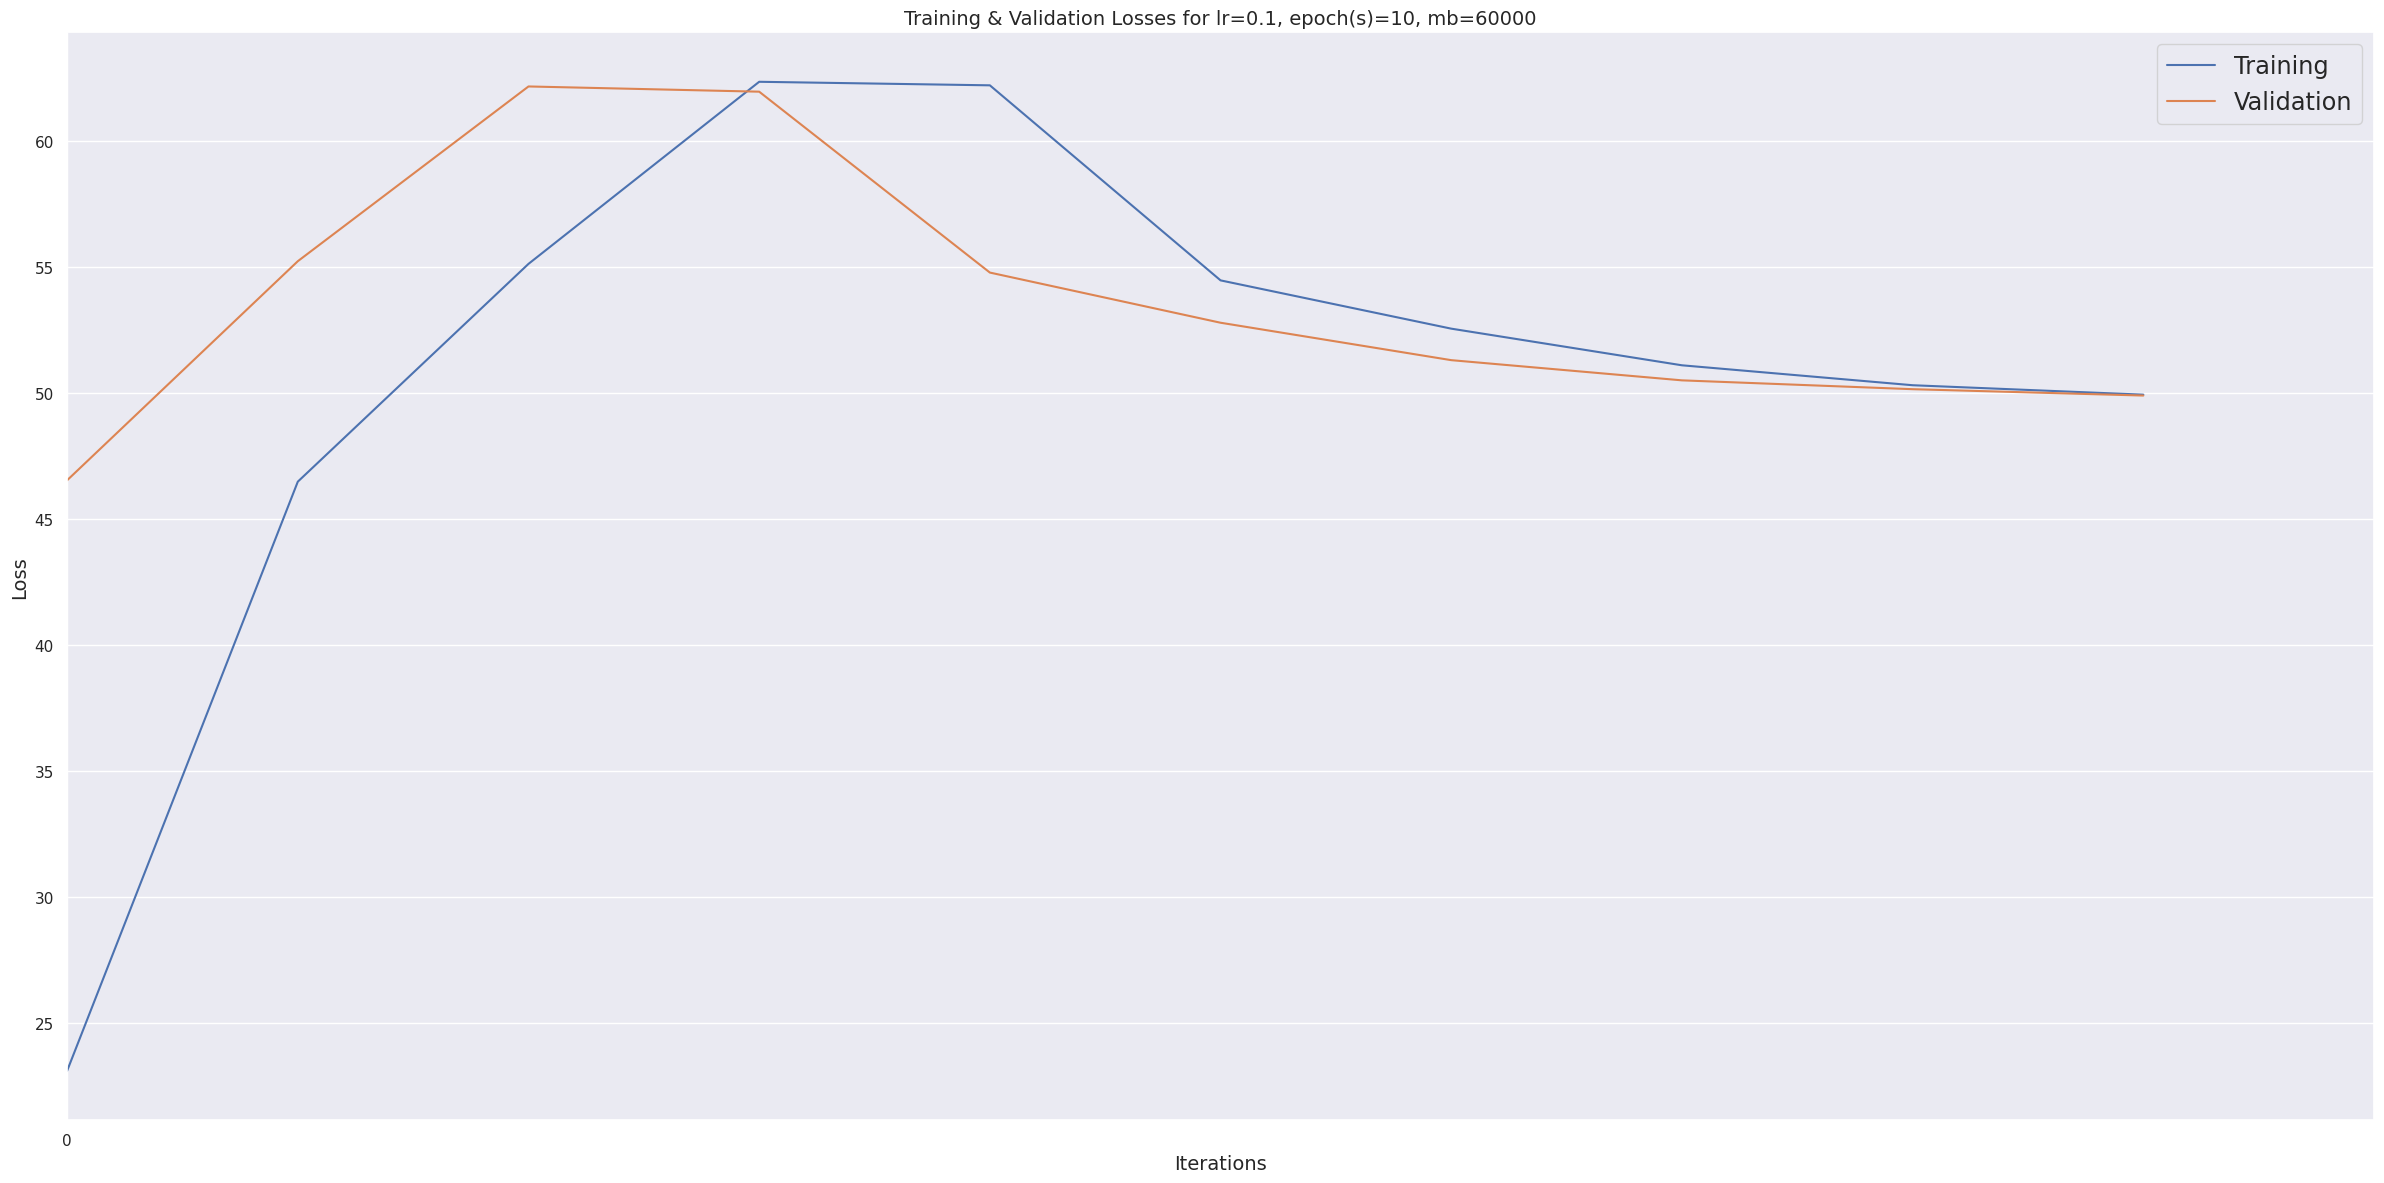

In [8]:
Utils.two_line_plot(
    x_ticks_inc=250
    , y1_legend="Training"
    , y_axis_label="Loss"
    , y2_legend="Validation"
    , x_axis_label="Iterations"
    , fig_size=(2 * 2 * 2 * 3, 2 * 2 * 3)
    , x=[tld.iter_idx for tld in net1_idps]
    , y1=[tld.training_loss for tld in net1_idps]
    , y2=[tld.validation_loss for tld in net1_idps]
    , title=f"Training & Validation Losses for lr={net1.lr}, epoch(s)={net1.n_epochs}, mb={net1.mini_batch_size}"
)

In [9]:
net2 = FeedFwdNN(
    lr=0.01
    , X_val=X_val
    , Y_val=Y_val
    , idx_val=idx_val
    , X_train=X_train
    , Y_train=Y_train
    , idx_train=idx_train
    , n_epochs=SMOKE_TEST_EPOCHS if SMOKE_TEST else Consts.N_EPOCHS
    , mini_batch_size=Consts.MINI_BATCH_SIZE
)

net2_idps = net1.train_and_validate()

FeedFwdNN.__init__:
	+ n_epochs: 10
	+ mini_batch_size: 60000
	+ lr: 0.01



  0%|          | 0/10 [00:00<?, ?it/s]

 10%|█         | 1/10 [00:00<00:01,  7.86it/s]

 20%|██        | 2/10 [00:00<00:01,  7.53it/s]

 30%|███       | 3/10 [00:00<00:00,  7.06it/s]

...

 70%|███████   | 7/10 [00:01<00:00,  6.61it/s]

 80%|████████  | 8/10 [00:01<00:00,  6.29it/s]

 90%|█████████ | 9/10 [00:01<00:00,  5.23it/s]

100%|██████████| 10/10 [00:01<00:00,  5.61it/s]

100%|██████████| 10/10 [00:01<00:00,  6.20it/s]

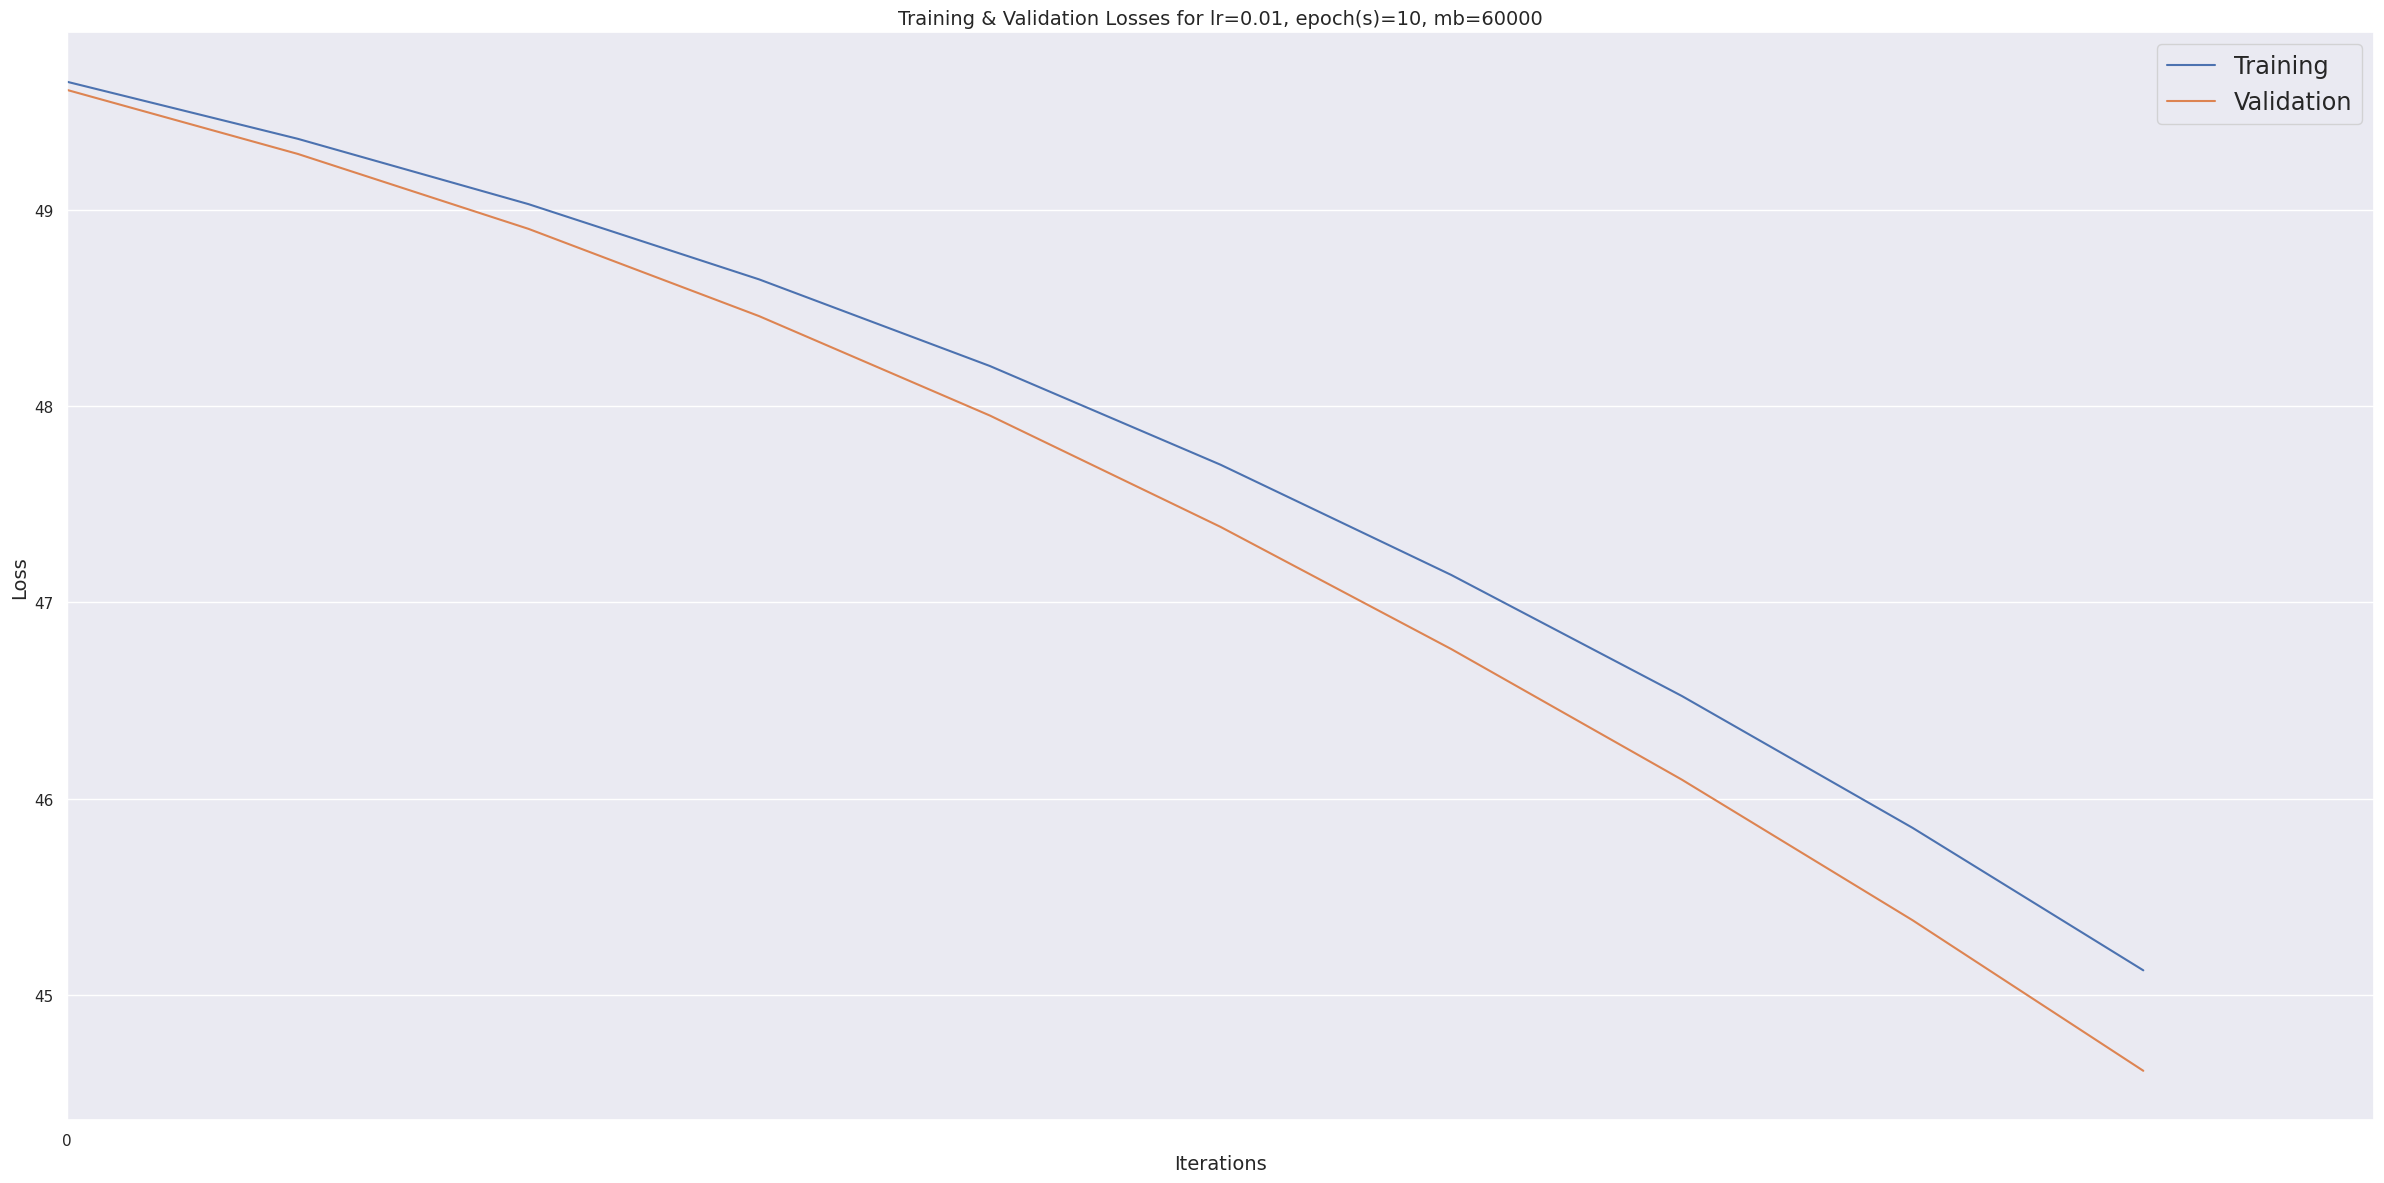

In [10]:
Utils.two_line_plot(
    x_ticks_inc=250
    , y1_legend="Training"
    , y_axis_label="Loss"
    , y2_legend="Validation"
    , x_axis_label="Iterations"
    , fig_size=(2 * 2 * 2 * 3, 2 * 2 * 3)
    , x=[tld.iter_idx for tld in net2_idps]
    , y1=[tld.training_loss for tld in net2_idps]
    , y2=[tld.validation_loss for tld in net2_idps]
    , title=f"Training & Validation Losses for lr={net2.lr}, epoch(s)={net2.n_epochs}, mb={net2.mini_batch_size}"
)

In [11]:
min(net1_idps, key=lambda idp: idp.validation_loss).validation_loss

46.52748182487309

In [12]:
min(net2_idps, key=lambda idp: idp.validation_loss).validation_loss

44.612721177623165